# Laboratorio 1: Herramientas básicas para Aprendizaje Automático

**Curso:** Aprendizaje Automático  
**Tipo:** Laboratorio teórico-práctico  
**Tema:** Introducción a `pandas`, `numpy`, `matplotlib` y `seaborn`

---

## Objetivo del laboratorio

En este laboratorio aprenderás a utilizar las herramientas fundamentales del flujo de trabajo en ciencia de datos y aprendizaje automático. La idea no es solo ejecutar código, sino también entender por qué estas bibliotecas son importantes y cómo se conectan entre sí dentro de un proyecto real.

Al finalizar, podrás:

- Cargar y explorar datos tabulares.
- Realizar operaciones numéricas básicas.
- Crear visualizaciones simples e interpretarlas.
- Comprender la diferencia entre manipulación, cálculo y visualización de datos.

## 1. Introducción teórica

En aprendizaje automático, antes de entrenar cualquier modelo, es necesario comprender los datos. En la práctica, gran parte del trabajo inicial consiste en:

1. **Cargar datos**
2. **Explorarlos**
3. **Limpiarlos**
4. **Transformarlos**
5. **Visualizarlos**

Este laboratorio se concentra en esas primeras etapas.

### ¿Qué hace cada herramienta?

- **Pandas**: permite trabajar con tablas de datos de forma cómoda y potente.
- **NumPy**: facilita el cálculo numérico y el trabajo con arreglos.
- **Matplotlib**: permite crear gráficos básicos y personalizables.
- **Seaborn**: construye gráficos estadísticos más expresivos sobre Matplotlib.

Estas herramientas suelen usarse juntas. Por ejemplo, es común cargar un dataset con Pandas, calcular estadísticas con NumPy y visualizar resultados con Matplotlib o Seaborn.

## 2. Preparación del entorno

Si estás trabajando en un entorno donde las bibliotecas no están instaladas, puedes usar:

```bash
pip install pandas numpy matplotlib seaborn
```

En muchos entornos académicos o en Jupyter Notebook estas bibliotecas ya vienen disponibles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme()
plt.rcParams["figure.figsize"] = (8, 5)

## 3. Carga del dataset

Para este laboratorio usaremos el conjunto de datos **Iris**, uno de los datasets más conocidos en aprendizaje automático. Contiene mediciones de flores de tres especies distintas.

### Variables del dataset

- `sepal_length`: longitud del sépalo
- `sepal_width`: ancho del sépalo
- `petal_length`: longitud del pétalo
- `petal_width`: ancho del pétalo
- `species`: especie de la flor

Este dataset es útil porque es pequeño, limpio y fácil de interpretar, ideal para una primera práctica.

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
106,4.9,2.5,4.5,1.7,virginica
81,5.5,2.4,3.7,1.0,versicolor
6,4.6,3.4,1.4,0.3,setosa
17,5.1,3.5,1.4,0.3,setosa
29,4.7,3.2,1.6,0.2,setosa
24,4.8,3.4,1.9,0.2,setosa
23,5.1,3.3,1.7,0.5,setosa
95,5.7,3.0,4.2,1.2,versicolor
3,4.6,3.1,1.5,0.2,setosa
37,4.9,3.6,1.4,0.1,setosa


## 4. Exploración inicial con Pandas

Pandas trabaja principalmente con una estructura llamada **DataFrame**, que puede entenderse como una tabla donde:

- Cada fila representa una observación.
- Cada columna representa una variable.

Explorar un dataset significa responder preguntas como:

- ¿Cuántas filas y columnas tiene?
- ¿Qué tipos de datos contiene?
- ¿Hay valores faltantes?
- ¿Cómo se distribuyen las variables numéricas?

Estas preguntas son fundamentales antes de pensar en cualquier modelo.

In [4]:
# Dimensiones del dataset
df.shape

(150, 5)

In [5]:
# Nombres de columnas
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [6]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
# Resumen estadístico de variables numéricas
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Actividad de reflexión

Responde en una celda Markdown aparte:

1. ¿Cuántas observaciones tiene el dataset?
2. ¿Cuántas variables numéricas hay?
3. ¿Cuál parece tener mayor dispersión?

## 5. Selección y filtrado de datos

Una de las tareas más comunes en análisis de datos es seleccionar columnas o filtrar filas según alguna condición.

Por ejemplo:

- Seleccionar una sola columna.
- Seleccionar varias columnas.
- Quedarse solo con las filas de una especie en particular.

Esto es importante porque rara vez trabajamos con todo el dataset al mismo tiempo; normalmente analizamos subconjuntos.

In [8]:
# Selección de una columna
df["species"].head()

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object

In [9]:
# Selección de varias columnas
df[["sepal_length", "petal_length"]].head()

,sepal_length,petal_length
0,5.1,1.4
1,4.9,1.4
2,4.7,1.3
3,4.6,1.5
4,5.0,1.4


In [10]:
# Filtrado por especie
setosa = df[df["species"] == "setosa"]
setosa.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
# Filtrado por condición numérica
df[df["sepal_length"] > 5.0].head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
10,5.4,3.7,1.5,0.2,setosa
14,5.8,4.0,1.2,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


### Idea teórica clave

Filtrar datos permite formular preguntas más concretas. Por ejemplo:

- ¿Cómo son solo las flores `setosa`?
- ¿Qué ocurre con las muestras que tienen pétalos muy largos?
- ¿Hay diferencias claras entre grupos?

En aprendizaje automático, esta capacidad es útil para análisis exploratorio, validación de calidad de datos y construcción de variables.

## 6. Limpieza y revisión de datos

En datasets reales es habitual encontrar problemas como:

- Valores nulos o faltantes
- Datos duplicados
- Formatos incorrectos
- Valores atípicos

Aunque el dataset Iris es bastante limpio, revisaremos igualmente estos aspectos porque forman parte del flujo real de trabajo.

In [12]:
# Valores nulos por columna
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [13]:
# Número de filas duplicadas
df.duplicated().sum()

np.int64(1)

In [14]:
# Eliminación de duplicados (solo como ejemplo)
df_sin_duplicados = df.drop_duplicates()
df_sin_duplicados.shape

(149, 5)

### Reflexión

Aunque en este caso casi no haya problemas, en proyectos reales esta etapa es crítica. Un modelo entrenado con datos de mala calidad suele producir resultados poco confiables, incluso si el algoritmo es muy avanzado.

## 7. Introducción a NumPy

NumPy es una biblioteca especializada en cálculo numérico eficiente. Su estructura central es el **array**, que permite trabajar con colecciones de números de manera rápida y compacta.

### ¿Por qué NumPy es tan importante?

Porque muchas operaciones matemáticas pueden aplicarse a todos los elementos de un arreglo al mismo tiempo, sin usar bucles explícitos. Esto se conoce como **vectorización**.

La vectorización suele ser más:

- rápida,
- clara,
- eficiente en memoria.

In [15]:
# Creación de arreglos con NumPy
vector = np.array([1, 2, 3, 4, 5])
matriz = np.array([[1, 2], [3, 4], [5, 6]])

print("Vector:")
print(vector)
print()
print("Matriz:")
print(matriz)

Vector:
[1 2 3 4 5]

Matriz:
[[1 2]
 [3 4]
 [5 6]]


In [16]:
# Operaciones básicas
print("Media de sepal_length:", np.mean(df["sepal_length"]))
print("Desviación estándar de sepal_length:", np.std(df["sepal_length"]))
print("Valor máximo de petal_length:", np.max(df["petal_length"]))
print("Valor mínimo de petal_width:", np.min(df["petal_width"]))

Media de sepal_length: 5.843333333333334
Desviación estándar de sepal_length: 0.8253012917851409
Valor máximo de petal_length: 6.9
Valor mínimo de petal_width: 0.1


In [17]:
# Operaciones vectorizadas
primeros_valores = df["sepal_length"].head().to_numpy()
print("Valores originales:", primeros_valores)
print("Valores multiplicados por 2:", primeros_valores * 2)

Valores originales: [5.1 4.9 4.7 4.6 5. ]
Valores multiplicados por 2: [10.2  9.8  9.4  9.2 10. ]


In [18]:
df["sepal_length"].head() * 2

0    10.2
1     9.8
2     9.4
3     9.2
4    10.0
Name: sepal_length, dtype: float64

### Idea teórica clave

Cuando trabajamos con datos numéricos, NumPy permite realizar cálculos agregados y transformaciones de forma muy eficiente. Esto será especialmente importante en etapas posteriores del curso, cuando se trabajen matrices, funciones de costo, gradientes o representaciones vectoriales.

## 8. Creación de nuevas variables

En ciencia de datos es frecuente construir nuevas variables a partir de las existentes. Este proceso se conoce como **ingeniería de características** o **feature engineering**.

Una nueva variable puede capturar mejor un patrón que las variables originales por separado.

In [19]:
# Nueva variable: área aproximada del sépalo
df["sepal_area"] = df["sepal_length"] * df["sepal_width"]

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area
0,5.1,3.5,1.4,0.2,setosa,17.85
1,4.9,3.0,1.4,0.2,setosa,14.70
2,4.7,3.2,1.3,0.2,setosa,15.04
3,4.6,3.1,1.5,0.2,setosa,14.26
4,5.0,3.6,1.4,0.2,setosa,18.00


In [20]:
df["sepal_area"].describe()

count    150.000000
mean      17.822867
std        3.361854
min       10.000000
25%       15.660000
50%       17.660000
75%       20.325000
max       30.020000
Name: sepal_area, dtype: float64

### Reflexión

La variable `sepal_area` no viene originalmente en el dataset, pero puede aportar una perspectiva diferente sobre el tamaño de la flor. En problemas reales, la creación de variables útiles puede mejorar significativamente el desempeño de un modelo.

## 9. Visualización con Matplotlib

Matplotlib es una de las bibliotecas más utilizadas para crear gráficos en Python. Permite representar visualmente patrones que serían difíciles de detectar solo leyendo tablas.

### ¿Por qué visualizar?

Porque los gráficos ayudan a responder preguntas como:

- ¿Cómo se distribuyen los datos?
- ¿Hay asimetrías?
- ¿Existen grupos o tendencias?
- ¿Hay puntos anómalos?

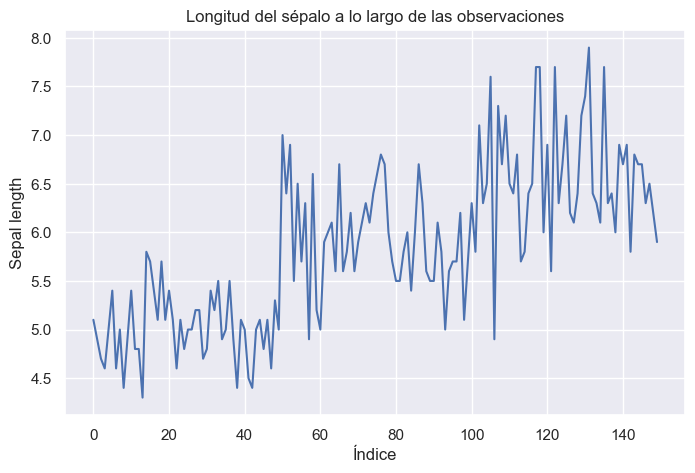

In [21]:
plt.plot(df["sepal_length"])
plt.title("Longitud del sépalo a lo largo de las observaciones")
plt.xlabel("Índice")
plt.ylabel("Sepal length")
plt.show()

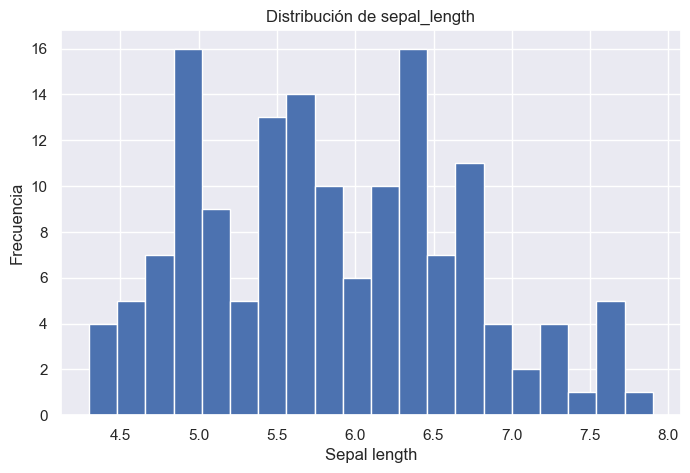

In [22]:
plt.hist(df["sepal_length"], bins=20)
plt.title("Distribución de sepal_length")
plt.xlabel("Sepal length")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación sugerida

El gráfico de línea permite observar cómo cambian los valores a lo largo del dataset, mientras que el histograma ayuda a estudiar la distribución de frecuencias. En esta etapa no solo importa hacer el gráfico, sino también describir qué información aporta.

## 10. Visualización estadística con Seaborn

Seaborn construye gráficos de alto nivel, especialmente útiles para análisis exploratorio. Además de mejorar la estética, facilita visualizar relaciones entre variables y separar grupos por categorías.

En datasets con clases, como Iris, esto es especialmente útil para explorar si las categorías son visualmente distinguibles.

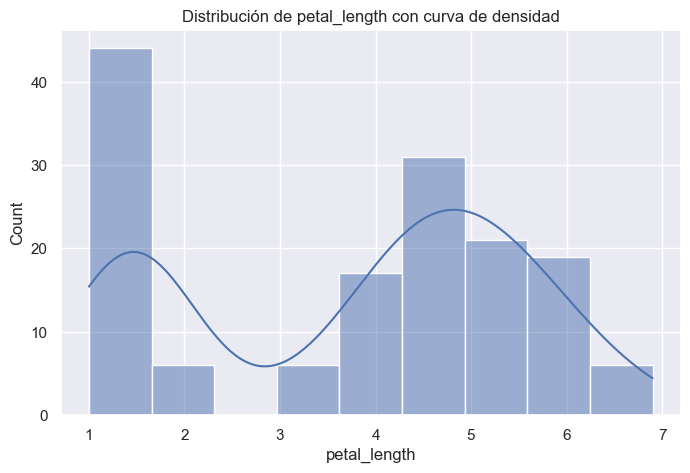

In [23]:
sns.histplot(data=df, x="petal_length", kde=True)
plt.title("Distribución de petal_length con curva de densidad")
plt.show()

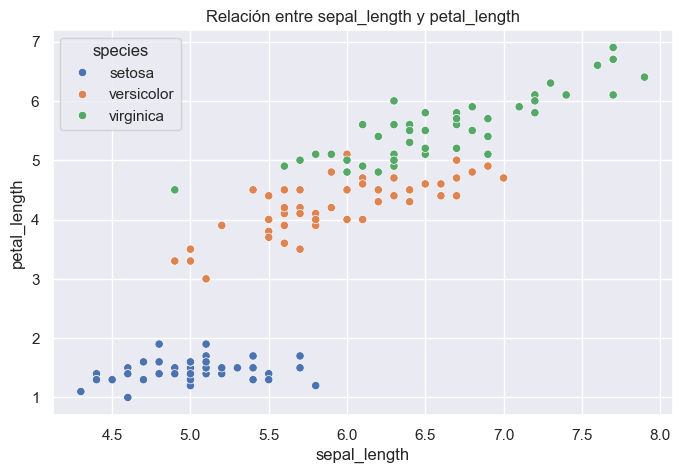

In [24]:
sns.scatterplot(data=df, x="sepal_length", y="petal_length", hue="species")
plt.title("Relación entre sepal_length y petal_length")
plt.show()

In [25]:
correlacion = df.select_dtypes(include=np.number).corr()
correlacion

,sepal_length,sepal_width,petal_length,petal_width,sepal_area
sepal_length,1.000000,-0.117570,0.871754,0.817941,0.679180
sepal_width,-0.117570,1.000000,-0.428440,-0.366126,0.643461
petal_length,0.871754,-0.428440,1.000000,0.962865,0.360909
petal_width,0.817941,-0.366126,0.962865,1.000000,0.368845
sepal_area,0.679180,0.643461,0.360909,0.368845,1.000000


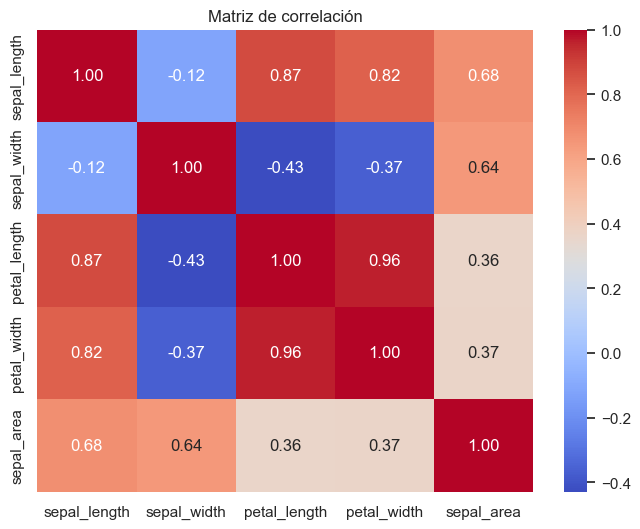

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

### Idea teórica clave

La **correlación** mide el grado de relación lineal entre dos variables numéricas. Sus valores suelen estar entre -1 y 1:

- cercano a **1**: relación positiva fuerte
- cercano a **-1**: relación negativa fuerte
- cercano a **0**: poca relación lineal

La correlación no implica causalidad, pero sirve como punto de partida para entender el comportamiento conjunto de las variables.

## 11. Agrupamiento y resumen por categoría

Otra operación común en Pandas es agrupar datos por una variable categórica y calcular estadísticas por grupo.

Esto permite comparar clases, categorías o segmentos.

In [27]:
df.groupby("species").mean(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width,sepal_area
species,,,,,
setosa,5.006,3.428,1.462,0.246,17.2578
versicolor,5.936,2.770,4.260,1.326,16.5262
virginica,6.588,2.974,5.552,2.026,19.6846


In [28]:
df.groupby("species").agg(["mean", "std"])[["sepal_length", "petal_length"]]

sepal_length           petal_length          
                   mean       std         mean       std
species                                                 
setosa            5.006  0.352490        1.462  0.173664
versicolor        5.936  0.516171        4.260  0.469911
virginica         6.588  0.635880        5.552  0.551895

### Reflexión

Estas tablas permiten comparar especies. Por ejemplo, puedes identificar cuál tiene mayor longitud promedio de pétalo o cuál presenta mayor variabilidad.

## 12. Ejercicio guiado

Desarrolla las siguientes actividades en nuevas celdas:

1. Filtra solo la especie `virginica`.
2. Calcula el promedio de `petal_width` para esa especie.
3. Crea un histograma de `sepal_area`.
4. Genera un gráfico de dispersión entre `sepal_width` y `petal_width`.
5. Escribe una breve interpretación de cada gráfico.

### Solución del ejercicio guiado

In [29]:
# 12.1 Filtra solo la especie virginica
virginica = df[df["species"] == "virginica"]
virginica.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area
100,6.3,3.3,6.0,2.5,virginica,20.79
101,5.8,2.7,5.1,1.9,virginica,15.66
102,7.1,3.0,5.9,2.1,virginica,21.30
103,6.3,2.9,5.6,1.8,virginica,18.27
104,6.5,3.0,5.8,2.2,virginica,19.50


In [30]:
# 12.2 Promedio de petal_width para virginica
promedio_petal_width = virginica["petal_width"].mean()
print(f"Promedio de petal_width (virginica): {promedio_petal_width:.3f}")

Promedio de petal_width (virginica): 2.026


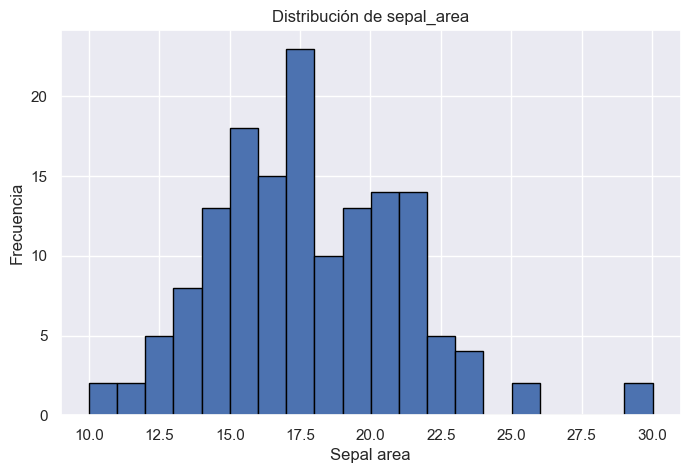

In [31]:
# 12.3 Histograma de sepal_area
plt.hist(df["sepal_area"], bins=20, edgecolor="black")
plt.title("Distribución de sepal_area")
plt.xlabel("Sepal area")
plt.ylabel("Frecuencia")
plt.show()

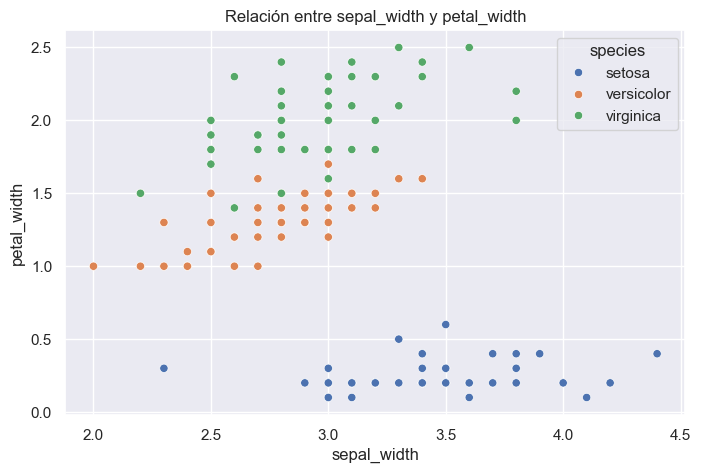

In [32]:
# 12.4 Dispersión entre sepal_width y petal_width
sns.scatterplot(data=df, x="sepal_width", y="petal_width", hue="species")
plt.title("Relación entre sepal_width y petal_width")
plt.show()

**Interpretaciones:**

- **Histograma de `sepal_area`:** la distribución es aproximadamente unimodal y ligeramente asimétrica a la derecha, con la mayor parte de los valores entre 15 y 22.
- **Dispersión `sepal_width` vs `petal_width`:** se observan grupos por especie. *setosa* tiene `petal_width` muy pequeño y `sepal_width` mayor, mientras que *virginica* concentra los valores de `petal_width` más altos.

## 13. Ejercicio de reto

Realiza un pequeño análisis exploratorio respondiendo:

1. ¿Qué especie parece separarse mejor de las demás?
2. ¿Qué variables parecen más relacionadas?
3. ¿La variable `sepal_area` ayuda a distinguir especies?
4. ¿Qué diferencias observas entre usar una tabla y usar un gráfico para analizar el mismo fenómeno?

Escribe tus respuestas en celdas Markdown.

### Respuestas del ejercicio de reto

1. **¿Qué especie se separa mejor?** *setosa* es la más fácilmente separable: sus pétalos son notablemente más cortos y angostos, lo que la aísla del resto en la mayoría de los gráficos.
2. **Variables más relacionadas:** `petal_length` y `petal_width` muestran la correlación más alta (≈ 0.96). Tambien `sepal_length` y `petal_length` están fuertemente correlacionadas.
3. **¿`sepal_area` ayuda a distinguir especies?** Aporta información parcial: el promedio difiere por especie, pero el solapamiento entre *setosa* y *versicolor* es notable. No es por sí sola tan discriminante como las variables de pétalo.
4. **Tabla vs gráfico:** la tabla resume valores puntuales (medias, desviaciones) pero oculta la forma de la distribución y los solapamientos; el gráfico revela patrones, agrupamientos y outliers que la tabla no muestra.

## 14. Conclusiones del laboratorio

En este laboratorio has trabajado con cuatro herramientas fundamentales del ecosistema de Python para análisis de datos:

- **Pandas** para organizar, filtrar y resumir datos.
- **NumPy** para cálculos numéricos eficientes.
- **Matplotlib** para gráficos básicos.
- **Seaborn** para visualización estadística más expresiva.

Estas bibliotecas forman parte del entorno base de trabajo en aprendizaje automático. Dominar su uso desde el inicio facilita mucho las siguientes etapas del curso, como preprocesamiento, selección de características, entrenamiento de modelos y evaluación.

## 15. Entregable

El estudiante debe entregar este notebook con:

- Todas las celdas ejecutadas.
- Las respuestas redactadas en las secciones de reflexión.
- Los gráficos solicitados.
- El ejercicio guiado y el reto resueltos.

---

## 16. Ejercicios adicionales (del PDF)

A continuación se resuelven los ejercicios 6, 7, 8, 9 y 10 propuestos en el documento del laboratorio.

### Ejercicio 6 — Filtrado y selección de datos (Pandas)

Dado un DataFrame con `nombre`, `edad` y `nota`:
a) Filtrar estudiantes con nota mayor a 14.
b) Filtrar estudiantes con edad mayor a 20 años.
c) Seleccionar únicamente las columnas `nombre` y `nota`.

In [33]:
estudiantes = pd.DataFrame({
    "nombre": ["Ana", "Luis", "María", "Carlos", "Lucía",
               "Jorge", "Elena", "Pedro", "Sofía", "Diego"],
    "edad":   [19, 22, 20, 25, 18, 21, 23, 19, 24, 20],
    "nota":   [15, 12, 18, 10, 17, 14, 16, 11, 19, 13],
})
estudiantes

,nombre,edad,nota
0,Ana,19,15
1,Luis,22,12
2,María,20,18
3,Carlos,25,10
4,Lucía,18,17
5,Jorge,21,14
6,Elena,23,16
7,Pedro,19,11
8,Sofía,24,19
9,Diego,20,13


In [34]:
# a) Estudiantes con nota mayor a 14
nota_alta = estudiantes[estudiantes["nota"] > 14]
nota_alta

,nombre,edad,nota
0,Ana,19,15
2,María,20,18
4,Lucía,18,17
6,Elena,23,16
8,Sofía,24,19


In [35]:
# b) Estudiantes con edad mayor a 20 años
mayores_20 = estudiantes[estudiantes["edad"] > 20]
mayores_20

,nombre,edad,nota
1,Luis,22,12
3,Carlos,25,10
5,Jorge,21,14
6,Elena,23,16
8,Sofía,24,19


In [36]:
# c) Selección de las columnas nombre y nota
estudiantes[["nombre", "nota"]]

,nombre,nota
0,Ana,15
1,Luis,12
2,María,18
3,Carlos,10
4,Lucía,17
5,Jorge,14
6,Elena,16
7,Pedro,11
8,Sofía,19
9,Diego,13


### Ejercicio 7 — Agrupamiento de datos

Dado un DataFrame con `carrera` y `nota`:
a) Promedio de notas por carrera.
b) Nota máxima por carrera.
c) Cantidad de estudiantes por carrera.

In [37]:
carreras = pd.DataFrame({
    "carrera": ["Sistemas", "Sistemas", "Industrial", "Industrial", "Civil",
                "Civil", "Sistemas", "Industrial", "Civil", "Sistemas"],
    "nota":    [15, 17, 12, 14, 18, 16, 13, 11, 19, 14],
})
carreras

,carrera,nota
0,Sistemas,15
1,Sistemas,17
2,Industrial,12
3,Industrial,14
4,Civil,18
5,Civil,16
6,Sistemas,13
7,Industrial,11
8,Civil,19
9,Sistemas,14


In [38]:
# a) Promedio de notas por carrera
carreras.groupby("carrera")["nota"].mean()

carrera
Civil         17.666667
Industrial    12.333333
Sistemas      14.750000
Name: nota, dtype: float64

In [39]:
# b) Nota máxima por carrera
carreras.groupby("carrera")["nota"].max()

carrera
Civil         19
Industrial    14
Sistemas      17
Name: nota, dtype: int64

In [40]:
# c) Cantidad de estudiantes por carrera
carreras.groupby("carrera")["nota"].count()

carrera
Civil         3
Industrial    3
Sistemas      4
Name: nota, dtype: int64

### Ejercicio 8 — Manipulación de columnas (Ventas)

a) Crear columna `IGV` (18% del valor de venta).
b) Crear columna `precio_total` (valor de venta + IGV).
c) Eliminar una columna innecesaria.

In [41]:
ventas = pd.DataFrame({
    "id_venta":        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "producto":        ["Laptop", "Mouse", "Teclado", "Monitor", "Impresora",
                        "USB 32GB", "Disco Duro", "Webcam", "Audífonos", "Silla Gamer"],
    "precio_unitario": [2500.00, 50.00, 120.00, 800.00, 600.00,
                        40.00, 350.00, 150.00, 200.00, 900.00],
    "cantidad":        [1, 2, 1, 2, 1, 3, 1, 2, 1, 1],
    "descuento":       [0.10, 0.00, 0.05, 0.08, 0.00, 0.02, 0.07, 0.00, 0.05, 0.12],
})

# Valor de venta = precio_unitario * cantidad * (1 - descuento)
ventas["valor_venta"] = ventas["precio_unitario"] * ventas["cantidad"] * (1 - ventas["descuento"])
ventas

,id_venta,producto,precio_unitario,cantidad,descuento,valor_venta
0,1,Laptop,2500.0,1,0.10,2250.0
1,2,Mouse,50.0,2,0.00,100.0
2,3,Teclado,120.0,1,0.05,114.0
3,4,Monitor,800.0,2,0.08,1472.0
4,5,Impresora,600.0,1,0.00,600.0
5,6,USB 32GB,40.0,3,0.02,117.6
6,7,Disco Duro,350.0,1,0.07,325.5
7,8,Webcam,150.0,2,0.00,300.0
8,9,Audífonos,200.0,1,0.05,190.0
9,10,Silla Gamer,900.0,1,0.12,792.0


In [42]:
# a) Columna IGV (18% del valor de venta)
ventas["IGV"] = ventas["valor_venta"] * 0.18

# b) Columna precio_total
ventas["precio_total"] = ventas["valor_venta"] + ventas["IGV"]
ventas

,id_venta,producto,precio_unitario,cantidad,descuento,valor_venta,IGV,precio_total
0,1,Laptop,2500.0,1,0.10,2250.0,405.000,2655.000
1,2,Mouse,50.0,2,0.00,100.0,18.000,118.000
2,3,Teclado,120.0,1,0.05,114.0,20.520,134.520
3,4,Monitor,800.0,2,0.08,1472.0,264.960,1736.960
4,5,Impresora,600.0,1,0.00,600.0,108.000,708.000
5,6,USB 32GB,40.0,3,0.02,117.6,21.168,138.768
6,7,Disco Duro,350.0,1,0.07,325.5,58.590,384.090
7,8,Webcam,150.0,2,0.00,300.0,54.000,354.000
8,9,Audífonos,200.0,1,0.05,190.0,34.200,224.200
9,10,Silla Gamer,900.0,1,0.12,792.0,142.560,934.560


In [43]:
# c) Eliminar una columna innecesaria (descuento ya quedó incorporado en valor_venta)
ventas_final = ventas.drop(columns=["descuento"])
ventas_final

,id_venta,producto,precio_unitario,cantidad,valor_venta,IGV,precio_total
0,1,Laptop,2500.0,1,2250.0,405.000,2655.000
1,2,Mouse,50.0,2,100.0,18.000,118.000
2,3,Teclado,120.0,1,114.0,20.520,134.520
3,4,Monitor,800.0,2,1472.0,264.960,1736.960
4,5,Impresora,600.0,1,600.0,108.000,708.000
5,6,USB 32GB,40.0,3,117.6,21.168,138.768
6,7,Disco Duro,350.0,1,325.5,58.590,384.090
7,8,Webcam,150.0,2,300.0,54.000,354.000
8,9,Audífonos,200.0,1,190.0,34.200,224.200
9,10,Silla Gamer,900.0,1,792.0,142.560,934.560


### Ejercicio 9 — Integración de datos

Dos DataFrames: `Estudiantes(id, nombre)` y `Notas(id, nota)`.
a) Unir ambos por `id`.
b) Mostrar únicamente los estudiantes que tienen notas registradas (inner join).

In [44]:
estudiantes_tbl = pd.DataFrame({
    "id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "nombre": ["Ana Pérez", "Luis Gómez", "María Torres", "Carlos Ruiz",
               "Lucía Fernández", "Jorge Castillo", "Elena Vargas",
               "Pedro Mendoza", "Sofía Herrera", "Diego Rojas"],
})

notas_tbl = pd.DataFrame({
    "id":   [1, 2, 3, 4, 5, 6, 8, 9, 10],
    "nota": [15, 12, 18, 10, 17, 14, 16, 11, 19],
})

estudiantes_tbl

,id,nombre
0,1,Ana Pérez
1,2,Luis Gómez
2,3,María Torres
3,4,Carlos Ruiz
4,5,Lucía Fernández
5,6,Jorge Castillo
6,7,Elena Vargas
7,8,Pedro Mendoza
8,9,Sofía Herrera
9,10,Diego Rojas


In [45]:
notas_tbl

,id,nota
0,1,15
1,2,12
2,3,18
3,4,10
4,5,17
5,6,14
6,8,16
7,9,11
8,10,19


In [46]:
# a) Unión de ambos DataFrames usando id (outer para conservar todos)
union_outer = pd.merge(estudiantes_tbl, notas_tbl, on="id", how="outer")
union_outer

,id,nombre,nota
0,1,Ana Pérez,15.0
1,2,Luis Gómez,12.0
2,3,María Torres,18.0
3,4,Carlos Ruiz,10.0
4,5,Lucía Fernández,17.0
5,6,Jorge Castillo,14.0
6,7,Elena Vargas,NaN
7,8,Pedro Mendoza,16.0
8,9,Sofía Herrera,11.0
9,10,Diego Rojas,19.0


In [47]:
# b) Solo estudiantes con notas registradas (inner join)
union_inner = pd.merge(estudiantes_tbl, notas_tbl, on="id", how="inner")
union_inner

,id,nombre,nota
0,1,Ana Pérez,15
1,2,Luis Gómez,12
2,3,María Torres,18
3,4,Carlos Ruiz,10
4,5,Lucía Fernández,17
5,6,Jorge Castillo,14
6,8,Pedro Mendoza,16
7,9,Sofía Herrera,11
8,10,Diego Rojas,19


### Ejercicio 10 — Ejercicio integrador

a) Cargar un CSV en un DataFrame.
b) Limpieza de datos.
c) Estadísticas descriptivas básicas.
d) Análisis de relaciones entre variables.
e) Tres conclusiones del análisis.

Se utiliza el dataset **Tips** (propinas de restaurante), de acceso público vía Seaborn.

In [48]:
# a) Cargar el CSV
url_tips = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url_tips)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [49]:
# Información general
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [50]:
# b) Limpieza de datos
print("Valores nulos por columna:")
print(tips.isnull().sum())
print()
print("Filas duplicadas:", tips.duplicated().sum())

# El dataset es limpio; igualmente eliminamos posibles duplicados por seguridad
tips_limpio = tips.drop_duplicates().reset_index(drop=True)
print("Forma final:", tips_limpio.shape)

Valores nulos por columna:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Filas duplicadas: 1
Forma final: (243, 7)


In [51]:
# c) Estadísticas descriptivas
tips_limpio.describe()

,total_bill,tip,size
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016
std,8.910071,1.385002,0.952356
min,3.070000,1.000000,1.000000
25%,13.380000,2.000000,2.000000
50%,17.810000,2.920000,2.000000
75%,24.175000,3.575000,3.000000
max,50.810000,10.000000,6.000000


In [52]:
# Resumen también para variables categóricas
tips_limpio.describe(include="object")

,sex,smoker,day,time
count,243,243,243,243
unique,2,2,4,2
top,Male,No,Sat,Dinner
freq,157,151,87,176


In [53]:
# d) Análisis de relaciones — matriz de correlación numérica
corr_tips = tips_limpio.select_dtypes(include=np.number).corr()
corr_tips

,total_bill,tip,size
total_bill,1.000000,0.674998,0.597589
tip,0.674998,1.000000,0.488400
size,0.597589,0.488400,1.000000


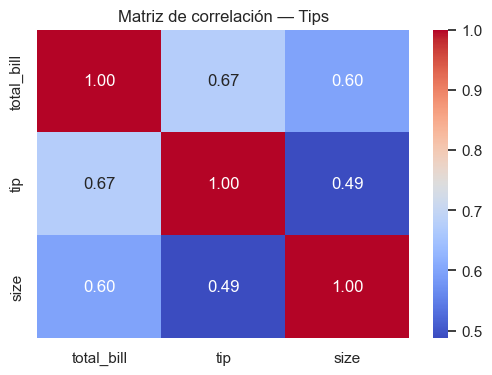

In [54]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_tips, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación — Tips")
plt.show()

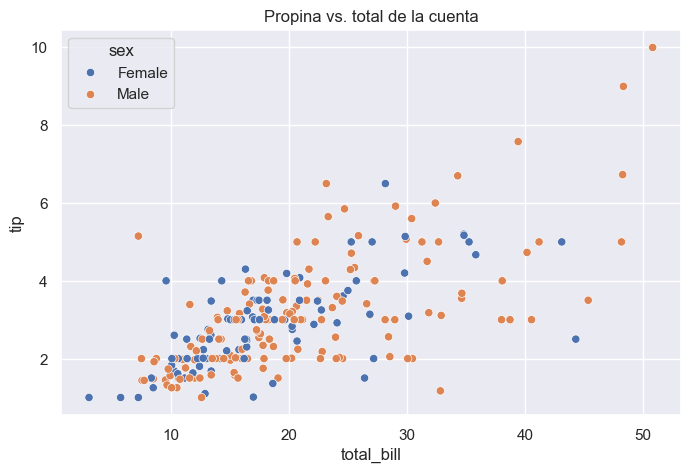

In [55]:
# Relación entre total_bill y tip, separando por género
sns.scatterplot(data=tips_limpio, x="total_bill", y="tip", hue="sex")
plt.title("Propina vs. total de la cuenta")
plt.show()

In [56]:
# Propina promedio por día y por momento (almuerzo / cena)
tips_limpio.groupby(["day", "time"], observed=True)["tip"].mean().unstack()

time,Dinner,Lunch
day,,
Fri,2.940000,2.382857
Sat,2.993103,NaN
Sun,3.255132,NaN
Thur,3.000000,2.780500


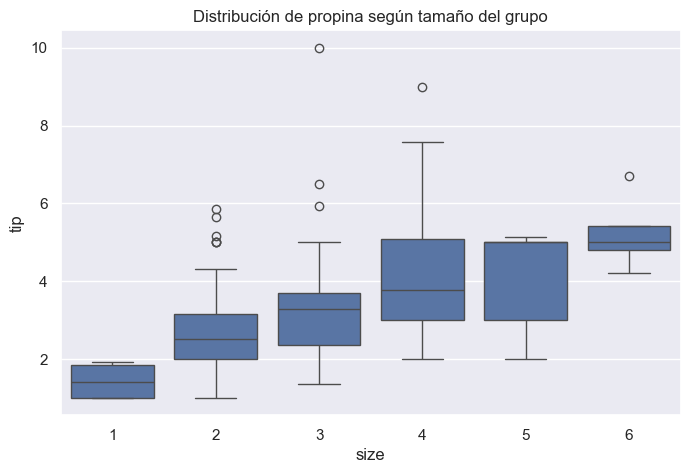

In [57]:
# Relación entre tamaño del grupo y propina
sns.boxplot(data=tips_limpio, x="size", y="tip")
plt.title("Distribución de propina según tamaño del grupo")
plt.show()

### e) Conclusiones

1. **Existe una relación positiva clara entre el total de la cuenta y la propina** (correlación ≈ 0.68): a mayor consumo, mayor propina absoluta. Es la relación más fuerte del dataset.
2. **El tamaño del grupo influye en la propina:** los grupos más grandes tienden a dejar propinas mayores en términos absolutos, aunque con mayor dispersión, lo que sugiere que el comportamiento individual varía más cuando hay más comensales.
3. **El día y el momento del servicio modifican el patrón:** las cenas (sobre todo de fin de semana) presentan propinas promedio mayores que los almuerzos, lo que probablemente se asocia a cuentas más altas y a un contexto social distinto.